Import libraries:

In [44]:
%pip install scikit-learn
%pip install seaborn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

import sys
!{sys.executable} -m pip install imbalanced-learn shap

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Load datasets (one COVID-positive and one COVID-negative):

In [45]:
DATA_POS = pd.read_csv("cleaned_COVID_dataV2.csv")  # COVID positive
DATA_NEG = pd.read_csv("cleaned_COVID_dataV3.csv")  # COVID negative


/var/folders/jm/mtsd0x1103b0p6429r3q67sr0000gn/T/ipykernel_63854/3283250500.py:1: DtypeWarning: Columns (0: DATE_DIED) have mixed types. Specify dtype option on import or set low_memory=False.
  DATA_POS = pd.read_csv("cleaned_COVID_dataV2.csv")  # COVID positive
/var/folders/jm/mtsd0x1103b0p6429r3q67sr0000gn/T/ipykernel_63854/3283250500.py:2: DtypeWarning: Columns (0: DATE_DIED) have mixed types. Specify dtype option on import or set low_memory=False.
  DATA_NEG = pd.read_csv("cleaned_COVID_dataV3.csv")  # COVID negative


Define features (X) and target variable:

In [46]:
features = ['AGE', 'DIABETES', 'HIPERTENSION', 'COPD', 'OBESITY',
            'SEX', 'ASTHMA', 'INMSUPR', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'TOBACCO', 'OTHER_DISEASE', 'PREGNANT']
target = 'DIED'

BOOL_COLS = ['SEX', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
             'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR',
             'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'OTHER_DISEASE', 'PREGNANT']

def preprocess(df):
    df = df.copy()
    df[target] = df[target].map({1: 1, 2: 0})
    for col in BOOL_COLS:
        if col not in df.columns:
            continue
        df[col] = df[col].replace({97: np.nan, 99: np.nan})
        if col in ('TOBACCO', 'PREGNANT'):
            df[col] = df[col].replace({3: np.nan})
        df[col] = df[col].replace({2: 0})
    return df

DATA_POS = preprocess(DATA_POS)
DATA_NEG = preprocess(DATA_NEG)

# Fill NaNs so that SVC works
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
DATA_POS[features] = imputer.fit_transform(DATA_POS[features])
DATA_NEG[features] = imputer.fit_transform(DATA_NEG[features])

df = DATA_POS.copy()

X_pos = DATA_POS[features]
y_pos = DATA_POS[target]

X_neg = DATA_NEG[features]
y_neg = DATA_NEG[target]

Split data into training and test sets:

In [47]:
# Model 1: COVID-positive (V2)
X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(
    X_pos, y_pos, test_size=0.2, random_state=42, stratify=y_pos)

# Model 2: COVID-negative (V3)
X_train_neg, X_test_neg, y_train_neg, y_test_neg = train_test_split(
    X_neg, y_neg, test_size=0.2, random_state=42, stratify=y_neg)


Scale the features:

In [48]:
scaler_pos = StandardScaler()
X_train_pos_scaled = scaler_pos.fit_transform(X_train_pos)
X_test_pos_scaled  = scaler_pos.transform(X_test_pos)

scaler_neg = StandardScaler()
X_train_neg_scaled = scaler_neg.fit_transform(X_train_neg)
X_test_neg_scaled  = scaler_neg.transform(X_test_neg)

Create Support Vector Machine model:

In [49]:
from sklearn.svm import LinearSVC
from sklearn.utils import resample

def train_svm(X_train_scaled, y_train):
    # Tuning on a subsample only
    X_tune, y_tune = resample(X_train_scaled, y_train,
                               n_samples=5000, random_state=42, stratify=y_train)
    
    param_dist = {'C': [0.01, 0.1, 1, 10]}  # LinearSVC only has C
    
    best_score = -1
    best_C = 1
    for C in param_dist['C']:
        m = LinearSVC(C=C, class_weight='balanced', random_state=42, max_iter=2000)
        from sklearn.model_selection import cross_val_score
        score = cross_val_score(m, X_tune, y_tune, cv=3, scoring='f1').mean()
        if score > best_score:
            best_score = score
            best_C = C
    print(f"Best C: {best_C} (F1={best_score:.3f})")
    
    # Final model trained on ALL data — takes only seconds
    svm_final = LinearSVC(C=best_C, class_weight='balanced',
                          random_state=42, max_iter=2000)
    svm_final.fit(X_train_scaled, y_train)
    return svm_final

print("=== Model 1: COVID-positive ===")
svm_pos = train_svm(X_train_pos_scaled, y_train_pos)

print("\n=== Model 2: COVID-negative ===")
svm_neg = train_svm(X_train_neg_scaled, y_train_neg)


=== Model 1: COVID-positive ===
Best C: 0.1 (F1=0.444)

=== Model 2: COVID-negative ===
Best C: 0.01 (F1=0.228)


Test and evaluate model:


In [ ]:
# === MODEL 1: COVID-positive ===
print("=== COVID-POSITIVE ===")
y_pred_pos = svm_pos.predict(X_test_pos_scaled)
print(classification_report(y_test_pos, y_pred_pos, target_names=['Survived (0)', 'Deceased (1)']))
print("Accuracy:", accuracy_score(y_test_pos, y_pred_pos))

# === MODEL 2: COVID-negative ===
print("\n=== COVID-NEGATIVE ===")
y_pred_neg = svm_neg.predict(X_test_neg_scaled)
print(classification_report(y_test_neg, y_pred_neg, target_names=['Survived (0)', 'Deceased (1)']))
print("Accuracy:", accuracy_score(y_test_neg, y_pred_neg))

=== COVID-POSITIVE (V2) ===
              precision    recall  f1-score   support

Survived (0)       0.87      0.59      0.71     15011
Deceased (1)       0.32      0.69      0.44      4186

    accuracy                           0.62     19197
   macro avg       0.60      0.64      0.57     19197
weighted avg       0.75      0.62      0.65     19197

Accuracy: 0.6159295723290097

=== COVID-NEGATIVE (V3) ===
              precision    recall  f1-score   support

Survived (0)       0.96      0.62      0.75     21773
Deceased (1)       0.13      0.69      0.22      1834

    accuracy                           0.62     23607
   macro avg       0.55      0.66      0.49     23607
weighted avg       0.90      0.62      0.71     23607

Accuracy: 0.6234591434743932


Visualize Confusion Matrix:

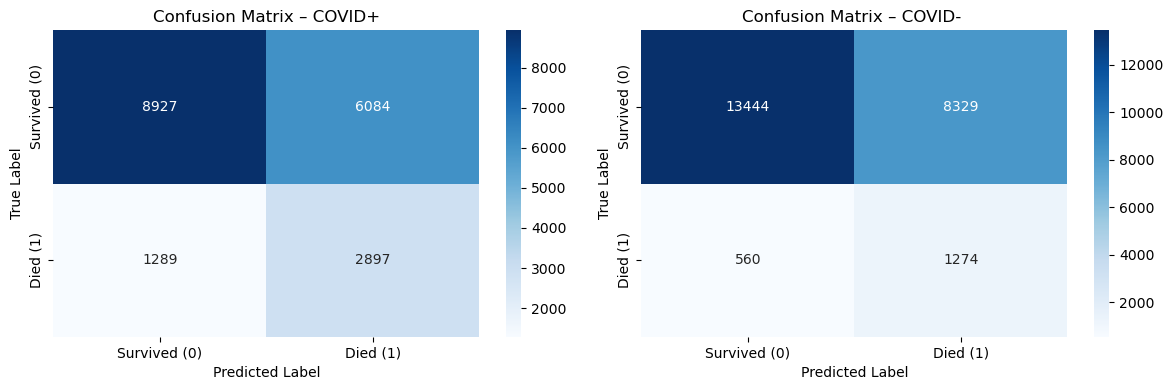

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (y_t, y_p, titel) in zip(axes, [
    (y_test_pos, y_pred_pos, 'COVID+'),
    (y_test_neg, y_pred_neg, 'COVID- ')
]):
    cm = confusion_matrix(y_t, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Survived (0)', 'Died (1)'],
                yticklabels=['Survived (0)', 'Died (1)'])
    ax.set_title(f'Confusion Matrix – {titel}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('1_confusion_matrix.png', dpi=150)
plt.show()

Display Feature Importance:

In [52]:
for svm_model, label in [(svm_pos, 'COVID-positive'), (svm_neg, 'COVID-negative')]:
    if hasattr(svm_model, 'coef_'):
        importance = svm_model.coef_[0]
        fi = pd.DataFrame({'Feature': features, 'Importance': importance})
        fi['AbsImportance'] = fi['Importance'].abs()
        fi = fi.sort_values('AbsImportance', ascending=False)
        print(f'\n=== Feature Importance: {label} ===')
        print(fi)
    else:
        print(f'{label}: coef_ not available (no linear kernel)')


=== Feature Importance: COVID-positive ===
           Feature  Importance  AbsImportance
0              AGE    0.260330       0.260330
10         TOBACCO   -0.115616       0.115616
6           ASTHMA   -0.106870       0.106870
5              SEX   -0.099792       0.099792
8   CARDIOVASCULAR   -0.083187       0.083187
11   OTHER_DISEASE   -0.048123       0.048123
3             COPD   -0.046656       0.046656
7          INMSUPR   -0.042611       0.042611
12        PREGNANT   -0.041938       0.041938
4          OBESITY   -0.034880       0.034880
1         DIABETES    0.015587       0.015587
9    RENAL_CHRONIC   -0.013113       0.013113
2     HIPERTENSION   -0.010341       0.010341

=== Feature Importance: COVID-negative ===
           Feature  Importance  AbsImportance
0              AGE    0.275258       0.275258
6           ASTHMA   -0.136216       0.136216
5              SEX   -0.121073       0.121073
10         TOBACCO   -0.106411       0.106411
4          OBESITY   -0.081734       0

Horizontal bar chart to display feature importance:

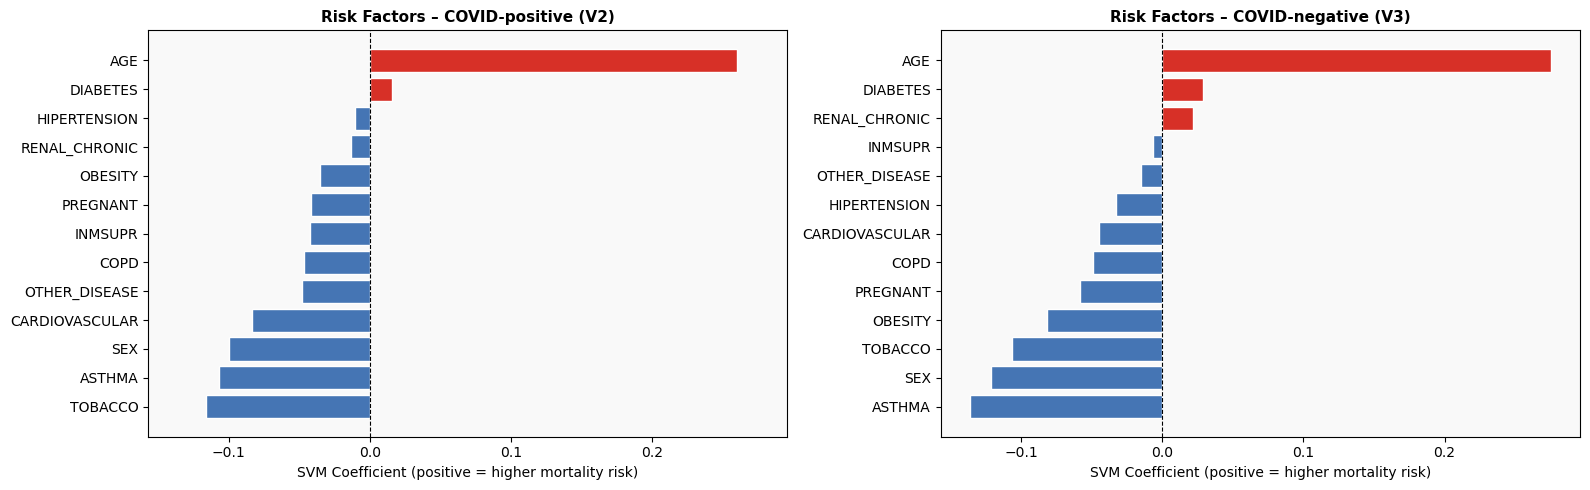

✓ Saved: 1_feature_importance.png


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (svm_model, label, fname) in zip(axes, [
    (svm_pos, 'COVID-positive (V2)', '1_feature_importance_pos.png'),
    (svm_neg, 'COVID-negative (V3)', '1_feature_importance_neg.png')
]):
    if not hasattr(svm_model, 'coef_'):
        ax.set_title(f'{label}: no linear kernel')
        continue
    importance = svm_model.coef_[0]
    fi = pd.DataFrame({'Feature': features, 'Coefficient': importance})
    fi = fi.sort_values('Coefficient')
    colors = ['#d73027' if v > 0 else '#4575b4' for v in fi['Coefficient']]
    ax.barh(fi['Feature'], fi['Coefficient'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('SVM Coefficient (positive = higher mortality risk)', fontsize=10)
    ax.set_title(f'Risk Factors – {label}', fontsize=11, fontweight='bold')
    ax.set_facecolor('#f9f9f9')

xlims = [ax.get_xlim() for ax in axes]
xmin = min(l[0] for l in xlims)
xmax = max(l[1] for l in xlims)
for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.savefig('1_feature_importance.png', dpi=150)
plt.show()
print("✓ Saved: 1_feature_importance.png")

ROC Curve:

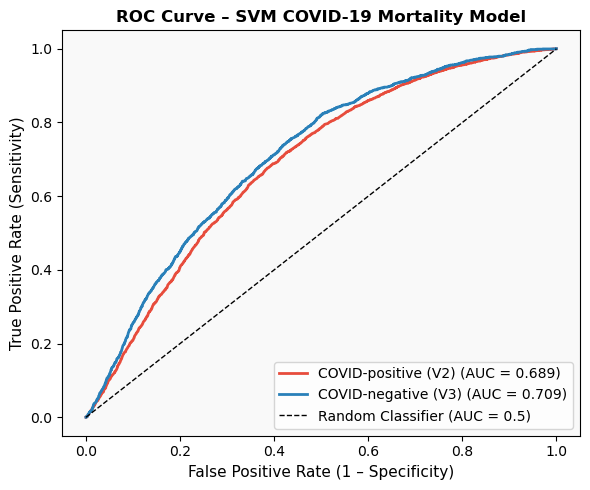

In [54]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6, 5))

for svm_model, X_test_sc, y_t, label, color in [
    (svm_pos, X_test_pos_scaled, y_test_pos, 'COVID-positive (V2)', '#e74c3c'),
    (svm_neg, X_test_neg_scaled, y_test_neg, 'COVID-negative (V3)', '#2980b9')
]:
    y_scores = svm_model.decision_function(X_test_sc)
    fpr, tpr, _ = roc_curve(y_t, y_scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 – Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve – SVM COVID-19 Mortality Model', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('2_roc_curve.png', dpi=150)
plt.show()

Precision-Recall Curve:

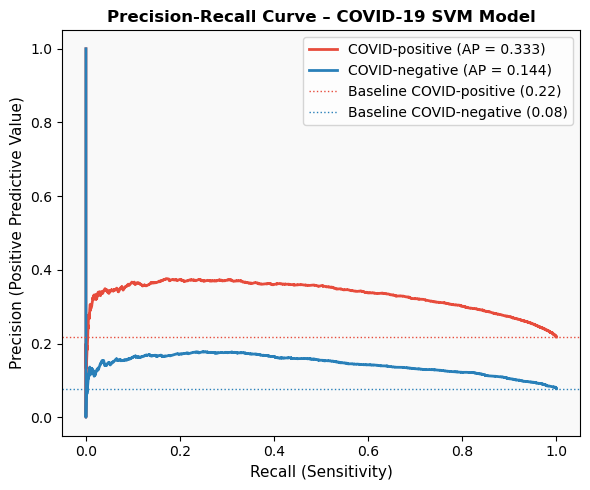

In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(6, 5))

for svm_model, X_test_sc, y_t, label, color in [
    (svm_pos, X_test_pos_scaled, y_test_pos, 'COVID-positive', '#e74c3c'),
    (svm_neg, X_test_neg_scaled, y_test_neg, 'COVID-negative', '#2980b9')
]:
    y_scores = svm_model.decision_function(X_test_sc)
    precision, recall, _ = precision_recall_curve(y_t, y_scores)
    ap = average_precision_score(y_t, y_scores)
    ax.plot(recall, precision, color=color, lw=2, label=f'{label} (AP = {ap:.3f})')

for base, color, label in [
    (y_test_pos.mean(), '#e74c3c', f'Baseline COVID-positive ({y_test_pos.mean():.2f})'),
    (y_test_neg.mean(), '#2980b9', f'Baseline COVID-negative ({y_test_neg.mean():.2f})')
]:
    ax.axhline(base, color=color, linestyle=':', lw=1, label=label)

ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
ax.set_title('Precision-Recall Curve – COVID-19 SVM Model', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('3_precision_recall.png', dpi=150)
plt.show()

Mortality rate per risk factor::

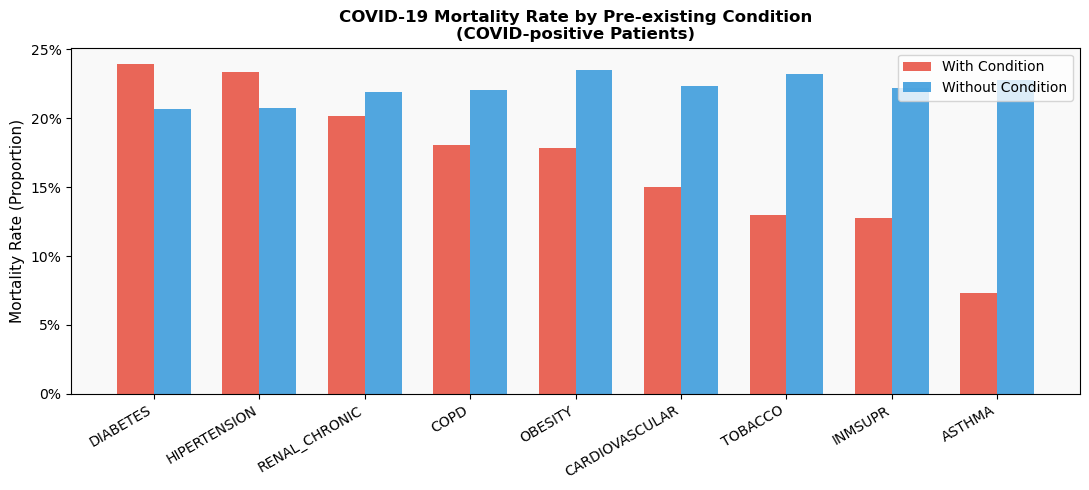

✓ Saved: 4_mortality_rate_per_risk_factor.png


In [62]:
binary_features = ['DIABETES', 'HIPERTENSION', 'COPD', 'OBESITY',
                   'ASTHMA', 'INMSUPR', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'TOBACCO']

mortality_rates = {}
for feat in binary_features:
    rate_with    = df[df[feat] == 1]['DIED'].mean()
    rate_without = df[df[feat] == 0]['DIED'].mean()
    mortality_rates[feat] = {'With Condition': rate_with, 'Without Condition': rate_without}

mr_df = pd.DataFrame(mortality_rates).T.reset_index()
mr_df.columns = ['Risk Factor', 'With Condition', 'Without Condition']
mr_df = mr_df.sort_values('With Condition', ascending=False)

x = np.arange(len(mr_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, mr_df['With Condition'],    width, label='With Condition',    color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + width/2, mr_df['Without Condition'], width, label='Without Condition', color='#3498db', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(mr_df['Risk Factor'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Mortality Rate (Proportion)', fontsize=11)
ax.set_title('COVID-19 Mortality Rate by Pre-existing Condition\n(COVID-positive Patients)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9f9')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
fig.tight_layout()
plt.savefig('4_mortality_rate_per_risk_factor.png', dpi=150)
plt.show()
print("✓ Saved: 4_mortality_rate_per_risk_factor.png")

Age Distribution: Deceased vs. Survived:

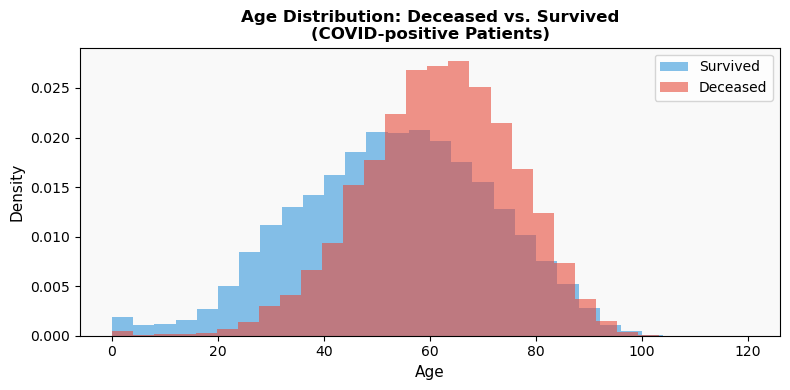

✓ Saved: 5_age_distribution.png


In [63]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df['DIED'] == 0]['AGE'].plot.hist(bins=30, alpha=0.6, color='#3498db',
                                      label='Survived', ax=ax, density=True)
df[df['DIED'] == 1]['AGE'].plot.hist(bins=30, alpha=0.6, color='#e74c3c',
                                      label='Deceased', ax=ax, density=True)
ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Age Distribution: Deceased vs. Survived\n(COVID-positive Patients)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#f9f9f9')
fig.tight_layout()
plt.savefig('5_age_distribution.png', dpi=150)
plt.show()
print("✓ Saved: 5_age_distribution.png")



Correlation Heatmap:

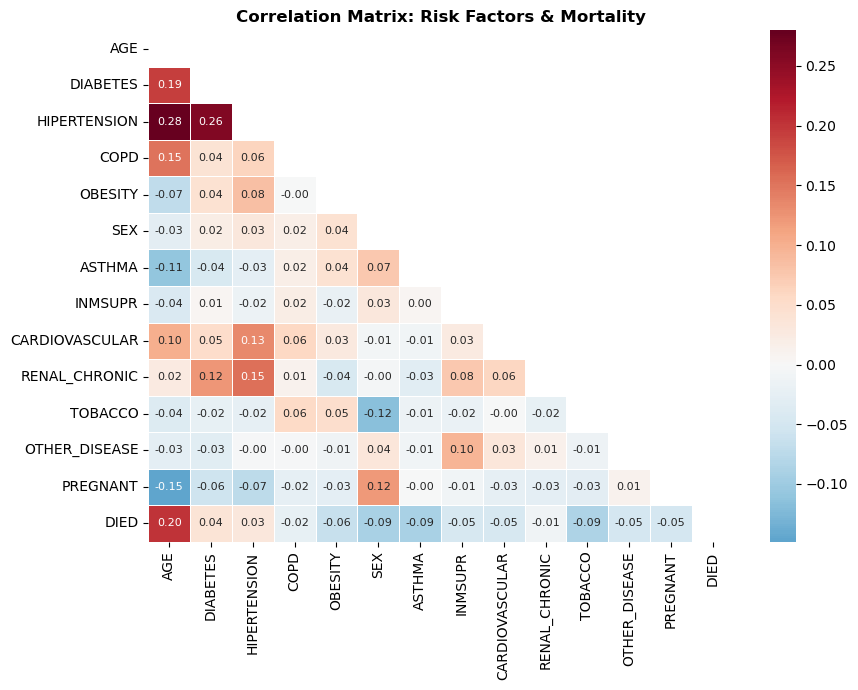

In [58]:
corr_features = features + ['DIED']
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix: Risk Factors & Mortality', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('6_correlation_heatmap.png', dpi=150)
plt.show()

SHAP Analysis - COVID positive:


>>> SHAP Analysis for COVID-positive
(Background=50, Evaluation=100, nsamples=100)


100%|██████████| 100/100 [00:00<00:00, 463.78it/s]


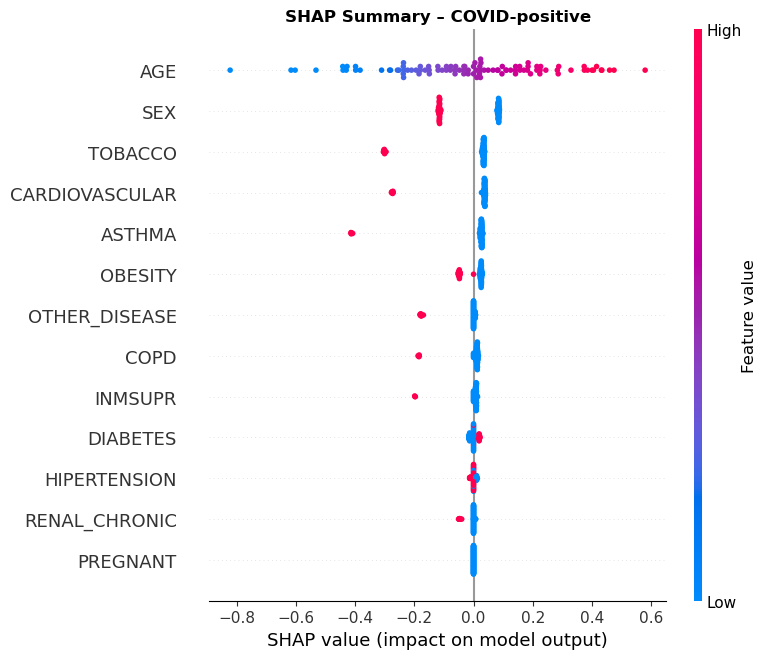

✓ Saved: shap_summary_COVID-positive.png

>>> SHAP Analysis for COVID-negative
(Background=50, Evaluation=100, nsamples=100)


100%|██████████| 100/100 [00:00<00:00, 284.19it/s]


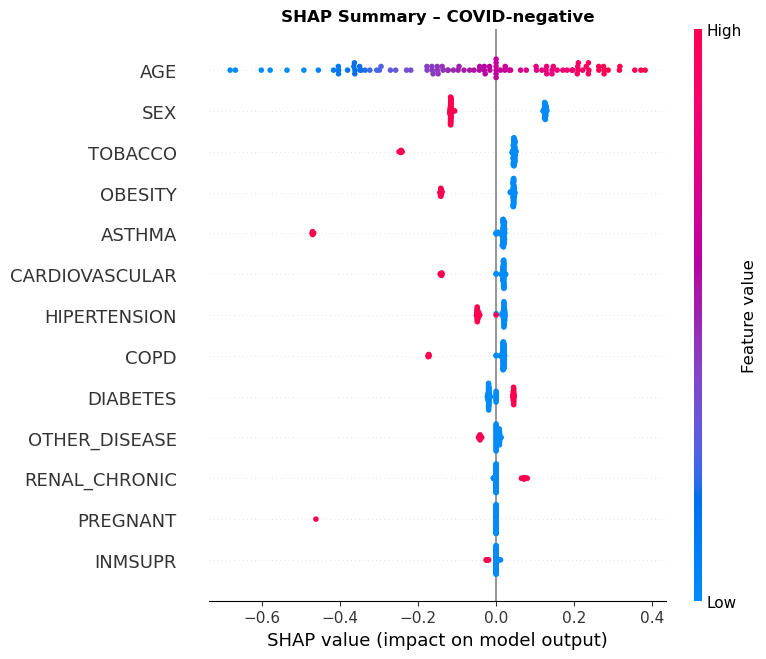

✓ Saved: shap_summary_COVID-negative.png


In [64]:
import shap
import numpy as np
import matplotlib.pyplot as plt

def run_shap(name, model, X_train_scaled, X_test_scaled, feat_names,
             n_background=50, n_eval=100, nsamples=100):
    """Apply SHAP KernelExplainer to LinearSVC model."""
    print(f"\n>>> SHAP Analysis for {name}")
    print(f"(Background={n_background}, Evaluation={n_eval}, nsamples={nsamples})")

    # Sample background and evaluation data
    idx_bg   = np.random.choice(len(X_train_scaled), n_background, replace=False)
    idx_eval = np.random.choice(len(X_test_scaled),  n_eval,       replace=False)
    background = X_train_scaled[idx_bg]
    eval_data  = X_test_scaled[idx_eval]

    # LinearSVC has no predict_proba → use decision_function
    explainer   = shap.KernelExplainer(model.decision_function, background)
    shap_values = explainer.shap_values(eval_data, nsamples=nsamples)

    # Save summary plot
    plt.figure()
    shap.summary_plot(shap_values, eval_data,
                      feature_names=feat_names, show=False)
    plt.title(f"SHAP Summary – {name}", fontweight='bold')
    plt.tight_layout()
    fname = f"shap_summary_{name.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"✓ Saved: {fname}")

    return {"name": name, "shap_values": shap_values, "eval_data": eval_data}


# SHAP for COVID-positive
shap_POS = run_shap(
    name           = "COVID-positive",
    model          = svm_pos,
    X_train_scaled = X_train_pos_scaled,
    X_test_scaled  = X_test_pos_scaled,
    feat_names     = features
)

# SHAP for COVID-negative
shap_NEG = run_shap(
    name           = "COVID-negative",
    model          = svm_neg,
    X_train_scaled = X_train_neg_scaled,
    X_test_scaled  = X_test_neg_scaled,
    feat_names     = features )